# 한국어 번역기

In [8]:
import pandas
import torch
import matplotlib

print(pandas.__version__)
print(torch.__version__)
print(matplotlib.__version__)

2.3.0
2.7.1+cu118
3.10.3


In [9]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 31.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 65.4 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: protobuf━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/19 [libclang]
    Found existing installation: protobuf 5.29.3━━━━━━━━━━━━━━  1/19 [libclang]
    Uninstalling protobuf-5.29.3:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  5/19 [protobuf]
      Successfully uninstalled protobuf-5.29.3━━━━━━━━━━━━━━━━  5/19 [protobuf]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19/19 [tensorflow]9 [tensorflow]
Note: you may need to restart the kernel to use updated packages.


In [10]:

!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 1.8 MB/s eta 0:00:00ta 0:00:01


In [11]:
import tensorflow as tf

# 1. 사용할 수 있는 장치 목록 확인
print("사용 가능한 장치 목록:", tf.config.list_physical_devices())

# 2. GPU가 정말로 인식되는지 확인
gpu_available = tf.config.list_physical_devices('GPU')
print(f"GPU 사용 가능 여부: {len(gpu_available) > 0}")

I0000 00:00:1778075356.575601     127 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778075358.547534     127 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


사용 가능한 장치 목록: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU 사용 가능 여부: False


W0000 00:00:1778075361.200709     127 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [35]:
import os
import re
import urllib.request
import tarfile
import sentencepiece as spm
import pandas as pd
import numpy as np
import tensorflow as tf
from konlpy.tag import Mecab
from tqdm import tqdm


I0000 00:00:1778066178.687906     192 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778066180.948018     192 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [7]:
# 1. 경로 설정
dataset_dir = os.path.expanduser("~/work/AIFFEL_quest_eng/NLP/NLP01/datasets")
os.makedirs(dataset_dir, exist_ok=True)
tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")


In [13]:

# 2. [중요] 기존에 잘못된 파일이 있다면 삭제 (다시 받기 위해)
if os.path.exists(tar_path):
    os.remove(tar_path)
    print("기존의 잘못된 파일을 삭제했습니다.")

# 3. 진짜 알맹이 주소 (Raw 주소인지 꼭 확인!)
# 주소에 'raw.githubusercontent.com'이 포함되어야 합니다.
url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"

# 4. 다시 다운로드
print("데이터 다운로드 중... ")
urllib.request.urlretrieve(url, tar_path)
print("다운로드 완료!")

기존의 잘못된 파일을 삭제했습니다.
데이터 다운로드 중... 
다운로드 완료!


In [8]:
data_folder = os.path.join(dataset_dir, "kor-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    # .tar.gz를 r(읽기)모드인데 gz(압축)된 상태로 열기
    with tarfile.open(tar_path, 'r:gz') as tar_ref: 
        tar_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "kor.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

압축 해제 중...


/tmp/ipykernel_192/3330861497.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_ref.extractall(dataset_dir)


압축 해제 완료!
데이터셋 디렉토리: ['korean-english-park.train.ko', 'korean-english-park.train.en', '.ipynb_checkpoints', 'korean-english-park.train.tar.gz']


In [9]:
ko_path = os.path.join(dataset_dir, "korean-english-park.train.ko")
en_path = os.path.join(dataset_dir, "korean-english-park.train.en")

In [10]:
# 각각의 파일에서 가져오기
with open(ko_path, "r", encoding="utf-8") as f:
    ko_lines = f.readlines()

with open(en_path, "r", encoding="utf-8") as f:
    en_lines = f.readlines()

# 표로 합치기
# strip()을 써서 문장 끝에 붙은 불필요한 줄바꿈(\n)을 지워주기
df = pd.DataFrame({
    "kor": [line.strip() for line in ko_lines],
    "eng": [line.strip() for line in en_lines]
})


print(f"전체 데이터 개수: {len(df)}")
df.head()

전체 데이터 개수: 94123


,kor,eng
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


#### 데이터 정제

In [25]:
# KoNLPy 라이브러리 설치
!pip install konlpy

# 파이썬이 시스템에 설치된 MeCab을 알아볼 수 있게 해주는 연결고리입니다.
!pip install mecab-python3

In [26]:
from konlpy.tag import Mecab
import re


In [27]:
def preprocess_sentence(sentence, is_korean=True):
    # 모두 소문자로 바꾸고 공백 지우기
    sentence = sentence.lower().strip()
    # 부호 양옆에 공백 넣어서 따로 볼 수 있게 하기
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    
    if is_korean:
        # 한글(가-힣, 자음, 모음)과 문장 부호만 남기고 다 지우기
        sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣ?.!,]+", " ", sentence)
    else:
        # 영어와 문장 부호만 남기고 다 지우기
        sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

In [28]:
df = df[:30000]
df["eng"] = df["eng"].apply(lambda x: preprocess_sentence(x, is_korean=False))
df["kor"] = df["kor"].apply(lambda x: preprocess_sentence(x, is_korean=True))

df.head()

,kor,eng
0,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,start start start start much of personal compu...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,start start start start so a mention a few wee...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,start start start start like all optical mice ...
3,". 달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어떤 부분이...",start start start start uses gyroscopic sensor...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,start start start start intelligence officials...


In [29]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["kor"].to_csv("kor_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, kor_corpus.txt")

파일 저장 완료: eng_corpus.txt, kor_corpus.txt


In [30]:
# 토큰 길이 40 이하 필터링 및 말뭉치 생성
kor_corpus = []
eng_corpus = []

for kor, eng in raw_corpus:
    pre_kor = preprocess_sentence(kor, is_korean=True)
    pre_eng = preprocess_sentence(eng, is_korean=False)
    
    # 토큰 개수가 40개 이하인 데이터만 선별
    if len(pre_kor.split()) <= 40 and len(pre_eng.split()) <= 40:
        kor_corpus.append(pre_kor)
        eng_corpus.append(pre_eng)

print(f"필터링 후 데이터 개수: {len(kor_corpus)}")

필터링 후 데이터 개수: 24219


In [31]:
# 토큰화 (Tensor 변환)
def tokenize(corpus, vocab_size=10000):
    tokenizer = tf.keras.preprocessing.text.Tokenizer(
        filters='', num_words=vocab_size
    )
    tokenizer.fit_on_texts(corpus)
    tensor = tokenizer.texts_to_sequences(corpus)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post')
    return tensor, tokenizer

# 루브릭 기준: 단어 수 10,000개 이상
VOCAB_SIZE = 10000
kor_tensor, kor_tokenizer = tokenize(kor_corpus, VOCAB_SIZE)
eng_tensor, eng_tokenizer = tokenize(eng_corpus, VOCAB_SIZE)

print("토큰화 완료!")

NameError: name 'tf' is not defined

In [10]:
# vocab_size = 3000
# pad_id = 0
# bos_id = 1
# eos_id = 2
# unk_id = 3

# spm.SentencePieceTrainer.train(
#     input = "kor_corpus.txt",
#     model_prefix = "encoder_spm",
#     vocab_size = vocab_size,
#     pad_id = pad_id,
#     bos_id = bos_id,
#     eos_id = eos_id,
#     unk_id = unk_id
# )

# spm.SentencePieceTrainer.train(
#     input = "eng_corpus.txt",
#     model_prefix = "decoder_spm",
#     vocab_size = vocab_size,
#     pad_id = pad_id,
#     bos_id = bos_id,
#     eos_id = eos_id,
#     unk_id = unk_id
# )

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: kor_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

In [6]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

NameError: name 'spm' is not defined

In [12]:
df

,kor,eng
0,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,much of personal computing is about can you to...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also doesn t ne..."
3,". 달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어떤 부분이...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,intelligence officials have revealed a spate o...
...,...,...
29995,일각에서는 대법원이 무샤라프의 당선은 무효라는 판결을 내릴 경우 그가 계엄령을 선포...,a majority a vast majority have voted for me a...
29996,미국 위스콘신 주 크랜든에서 일 오전 현지시간 비번이던 보안관이 총기를 난사해 명이...,cnn an off duty sheriff s deputy shot and kill...
29997,용의자는 타일러 피터슨은 크랜든 보안관겸 비 상근직 경찰로 근무해 온 것으로 알려졌다 .,"the deputy , tyler peterson , also worked part..."
29998,케이스 반 클레브 포레스트카운티 보안관은 피터슨이 대였다고 전했다 .,forest county sheriff keith van cleve said pet...


In [13]:
kor_sample = df["kor"][10000]
eng_sample = df["eng"][10000]

print(kor_sample)
print(eng_sample)

그는 민주당 대선후보가 결정 될 때까지 경선을 계속 치르겠다는 뜻을 밝힌 바 있다 .
clinton has vowed to stay in the race until someone gets enough delegates to clinch the nomination .


In [14]:
# 인코딩
enc_token = encoder_tokenizer.encode(kor_sample)
# 문장의 시작과 끝 번호 붙이기(bos시작/eos끝)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1,
 26,
 7,
 354,
 961,
 13,
 400,
 366,
 1941,
 789,
 6,
 413,
 647,
 55,
 947,
 7,
 4,
 2966,
 6,
 1634,
 117,
 33,
 5,
 2]

In [15]:
# 디코딩
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'그는 민주당 대선후보가 결정 될 때까지 경선을 계속 치르겠다는 뜻을 밝힌 바 있다 .'

In [16]:
from torch.utils.data import Dataset, DataLoader
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 한국어랑 영어 한문장씩 가져오기
        src_text = self.data.iloc[idx]['kor']
        trg_text = self.data.iloc[idx]['eng']
        # 글자를 숫자로 인코딩
        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)
        #문장 길이 자르기
        src_ids = src_ids[:self.max_len]

        # Decoder입력(시작, 끝 포함)
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 안맞으면 패딩으로 길이 맞춰주기
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))
        
        # 텐서에 담아서 반환
        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [17]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 문장 길이를 최애 30단어로
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [18]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


#### 모델 설계

In [19]:
import torch.nn as nn
# 어떤 단어에 집중할지 점수 매기는 클래스
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # 번역하려는 단어랑 원문 단어랑 비교해서 점수내기
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  
        # 에너지 점수 계산하고 소프트맥스로 단어 집중도 알려주기
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden)) 
        attention = self.v(energy).squeeze(2)  

        return nn.functional.softmax(attention, dim=1)  

In [20]:
# 한국어 읽고 의미 압축하는 인코더
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim) #단어를 좌표로 바꾸기
        self.rnn = nn.GRU(emb_dim, hidden_dim) #문장 흐름 기억하기

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src) 
        outputs, hidden = self.rnn(embedded)  

        return outputs, hidden

In [21]:
# 인코더 보고 영어를 한 단어씩 뱉는 디코더
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim) #다음 단어 예측하기

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)  
        embedded = self.embedding(input)  

        # attention으로 원문 어디를 볼지 결정하기 decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  
        context = torch.bmm(a, encoder_outputs) 
        context = context.permute(1, 0, 2)  

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 의미 context vector를 결합하여 예측값(영어단어) 생성
        output = output.squeeze(0)  
        context = context.squeeze(0)  
        prediction = self.fc_out(torch.cat((output, context), dim=1)) 

        return prediction, hidden, a.squeeze(1)

In [22]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None: # 학습할 때 trg 정답지 보면서 공부
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else: #테스트할때 정답 없이 때문에 sos_token을 생성
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1) #가장 확률 높은 단어 선택
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all(): #마침표 나오면 끝
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [24]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [25]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


In [26]:
model = Seq2SeqAttention(encoder, decoder, device).to(device)

#### 훈련하기

In [27]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)


In [28]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환. 모양 맞추기
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        # 이전 기울기 지우기
        optimizer.zero_grad()
        # 문제 풀기. 한국어 src보고 영어 trg_input 예측하기
        outputs,_ = model(src, trg_input)
        
        # 채점할 수 있게 결과를 한 줄로 길게 펴주기 (문장길이 * 배치 사이즈, 단어종류수)형태
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)


In [29]:
from tqdm.notebook import tqdm

In [47]:
%%time

EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/10, Train Loss: 5.1216


Epoch 2:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 2/10, Train Loss: 4.0933


Epoch 3:   0%|          | 0/375 [00:00<?, ?it/s]

...

Epoch 8/10, Train Loss: 1.6431


Epoch 9:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 9/10, Train Loss: 1.3921


Epoch 10:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 10/10, Train Loss: 1.1798
CPU times: user 6min 58s, sys: 8.69 s, total: 7min 7s
Wall time: 7min 1s


In [48]:
# 시험해보기
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모양 맞추기(길이, 배치) 순서로 바꾸고 보내기
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        # 인코더 디코더 모델에 한국어 넣어서 영어 예측하기
        outputs,_ = model(src, trg_input)
        # criterion 채점 규격에 맞게 결과 길게 펴기
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)
        # 실제 정답과 ai 답변이 얼마나 다른지 점수 매기기 ㅣoss
        loss = criterion(outputs, trg_label)
        
        total_loss += loss.item()
    # 전체 평균 점수 반환하기. 낮을 수록 좋음
    return total_loss / len(data_loader)


In [49]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/20, Train Loss: 0.9997, Validation Loss: 4.9297


Epoch 2:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 2/20, Train Loss: 0.8560, Validation Loss: 5.1186


Epoch 3:   0%|          | 0/375 [00:00<?, ?it/s]

...

Epoch 18/20, Train Loss: 0.2347, Validation Loss: 7.3750


Epoch 19:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 19/20, Train Loss: 0.2290, Validation Loss: 7.4591


Epoch 20:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 20/20, Train Loss: 0.2270, Validation Loss: 7.5585
CPU times: user 15min 9s, sys: 17.1 s, total: 15min 26s
Wall time: 15min 14s


In [50]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [51]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [52]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

In [55]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


Input: 커피는 필요 없다 .
Predicted translation: ['normal', 'ly', 'no', 'cat', 'are', 'availab', 'le', '.', '']


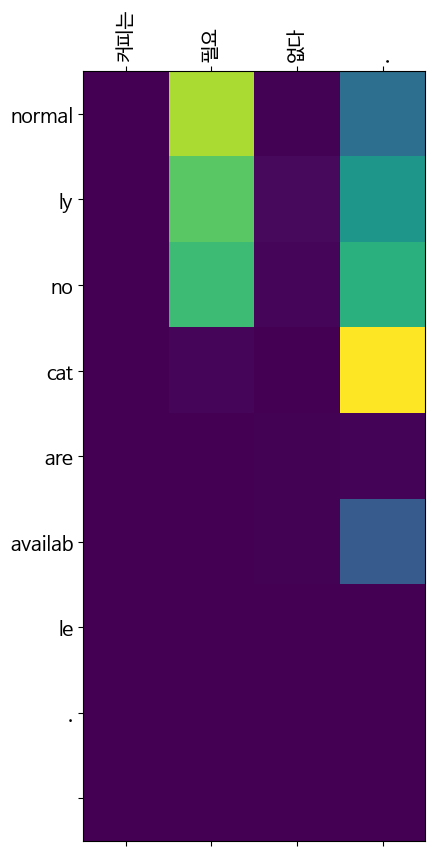

In [60]:
translate("커피는 필요 없다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 시민들은 도시 속에 산다 .
Predicted translation: ['san', 'die', 'go', '.', '']


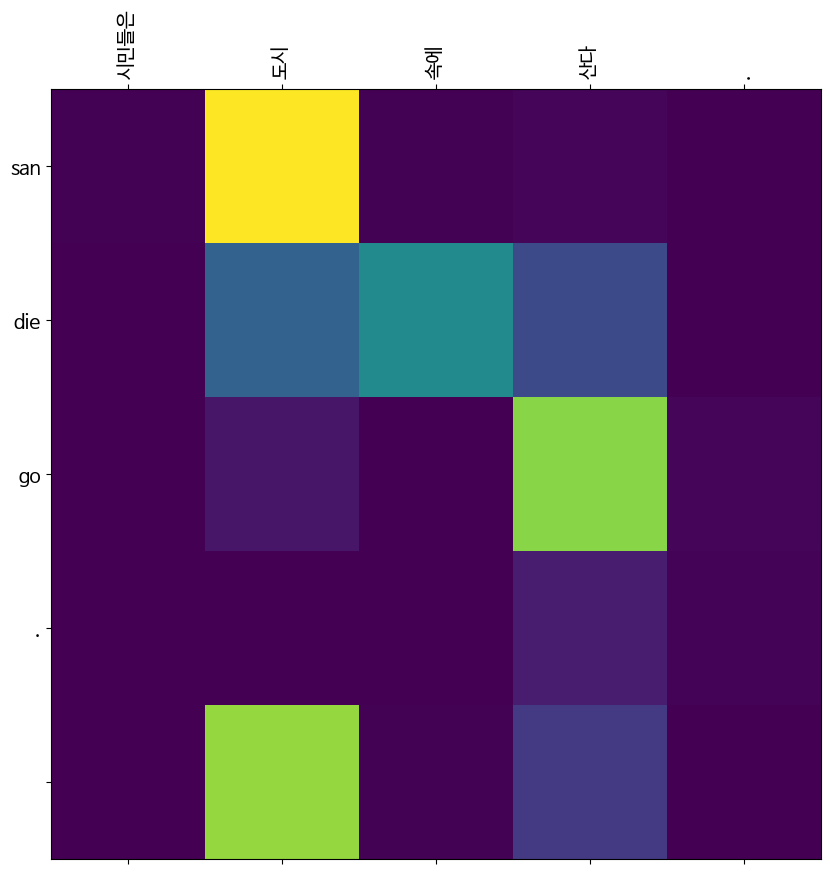

In [61]:
translate("시민들은 도시 속에 산다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 오바마는 대통령이다 .
Predicted translation: ['he', 'is', 'rev', 'ok', 'ed', '.', '']


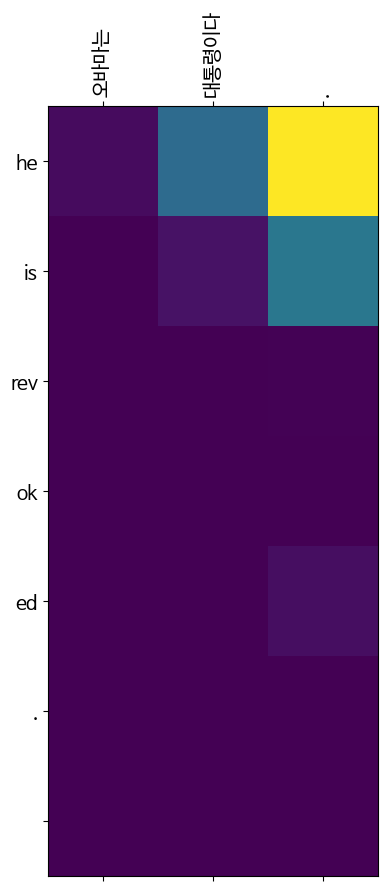

In [62]:
translate("오바마는 대통령이다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

In [63]:
# 모델 저장하기
torch.save(model.state_dict(), 'my_model.pth')
print("학습 결과 저장 완료! ")

학습 결과 저장 완료! 


In [27]:
import torch

# [저장하기] 학습 코드 안에서 에포크가 끝날 때마다 호출하면 좋아요.
# 모델의 가중치(공부한 내용)를 'my_model.pth'라는 이름의 파일로 저장합니다.
torch.save(model.state_dict(), 'checkpoint.pth')

# [불러오기] 커널 재시작 후, 모델 구조를 먼저 만든 다음 이 코드를 씁니다.
model.load_state_dict(torch.load('checkpoint.pth'))
model.eval() # "이제 공부 안 하고 실전(평가) 모드로 바꿀게!"라는 뜻

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)

#### 문제점 수정

제대로된 번역이 안되고 있음.

In [28]:
# KoNLPy 라이브러리 설치
!pip install konlpy

In [29]:
!curl -sL https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh | bash

mecab-ko is already installed
mecab-ko-dic is already installed
<string>:1: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
mecab-python is already installed
Done.


In [30]:
# KoNLPy 라이브러리 설치
!pip install konlpy

# 파이썬이 시스템에 설치된 MeCab을 알아볼 수 있게 해주는 연결고리입니다.
!pip install mecab-python3

In [31]:
!pip install python-mecab-ko

In [32]:
!pip install tensorflow

In [35]:
import os
import re
import pandas as pd
import numpy as np
import tensorflow as tf
from konlpy.tag import Mecab
from tqdm import tqdm

# 1. 중복 제거 (set 활용)
# zip으로 묶어서 쌍이 흐트러지지 않게 중복을 제거합니다.
raw_corpus = list(set(zip(df['kor'], df['eng'])))
print(f"중복 제거 전: {len(df)} -> 제거 후: {len(raw_corpus)}")

# 2. 한글 정규식을 포함한 전처리 함수 재정의
def preprocess_sentence(sentence, is_korean=True):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    if is_korean:
        # 한글과 문장 부호만 남기기
        sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣ?.!,]+", " ", sentence)
        mecab = Mecab()
        sentence = " ".join(mecab.morphs(sentence)) # 한글 토큰화 (Mecab)
    else:
        # 영어와 문장 부호만 남기기
        sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
        # 타겟 언어에 <start>, <end> 추가
        sentence = '<start> ' + sentence.strip() + ' <end>'
    
    return sentence.strip()


중복 제거 전: 30000 -> 제거 후: 29928


In [42]:
df

,kor,eng
0,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,much of personal computing is about can you to...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also doesn t ne..."
3,". 달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어떤 부분이...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,intelligence officials have revealed a spate o...
...,...,...
29995,일각에서는 대법원이 무샤라프의 당선은 무효라는 판결을 내릴 경우 그가 계엄령을 선포...,a majority a vast majority have voted for me a...
29996,미국 위스콘신 주 크랜든에서 일 오전 현지시간 비번이던 보안관이 총기를 난사해 명이...,cnn an off duty sheriff s deputy shot and kill...
29997,용의자는 타일러 피터슨은 크랜든 보안관겸 비 상근직 경찰로 근무해 온 것으로 알려졌다 .,"the deputy , tyler peterson , also worked part..."
29998,케이스 반 클레브 포레스트카운티 보안관은 피터슨이 대였다고 전했다 .,forest county sheriff keith van cleve said pet...


In [36]:

# 3. 토큰 길이 40 이하 필터링 및 말뭉치 생성
kor_corpus = []
eng_corpus = []

for kor, eng in raw_corpus:
    pre_kor = preprocess_sentence(kor, is_korean=True)
    pre_eng = preprocess_sentence(eng, is_korean=False)
    
    # 토큰 개수가 40개 이하인 데이터만 선별
    if len(pre_kor.split()) <= 40 and len(pre_eng.split()) <= 40:
        kor_corpus.append(pre_kor)
        eng_corpus.append(pre_eng)

print(f"필터링 후 데이터 개수: {len(kor_corpus)}")

# 4. 토큰화 (Tensor 변환)
def tokenize(corpus, vocab_size=10000):
    tokenizer = tf.keras.preprocessing.text.Tokenizer(
        filters='', num_words=vocab_size
    )
    tokenizer.fit_on_texts(corpus)
    tensor = tokenizer.texts_to_sequences(corpus)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post')
    return tensor, tokenizer

# 루브릭 기준: 단어 수 10,000개 이상
VOCAB_SIZE = 10000
kor_tensor, kor_tokenizer = tokenize(kor_corpus, VOCAB_SIZE)
eng_tensor, eng_tokenizer = tokenize(eng_corpus, VOCAB_SIZE)

print("토큰화 완료!")

필터링 후 데이터 개수: 23626
토큰화 완료!


In [47]:
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, query, values):
        # query: Decoder의 hidden state, values: Encoder의 출력
        hidden_with_time_axis = tf.expand_dims(query, 1)
        
        # 돋보기 점수 계산 (어느 단어를 중요하게 볼 것인가)
        score = self.V(tf.nn.tanh(self.W1(values) + self.W2(hidden_with_time_axis)))
        
        # 가중치 확률로 변환
        attention_weights = tf.nn.softmax(score, axis=1)
        
        # 최종 맥락(Context) 벡터 생성
        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units):
        super(Encoder, self).__init__()
        self.enc_units = enc_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(self.enc_units, return_sequences=True, return_state=True)

    def call(self, x, hidden):
        x = self.embedding(x)
        output, state = self.gru(x, initial_state=hidden)
        return output, state

class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, dec_units):
        super(Decoder, self).__init__()
        self.dec_units = dec_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(self.dec_units, return_sequences=True, return_state=True)
        self.fc = tf.keras.layers.Dense(vocab_size)
        self.attention = BahdanauAttention(self.dec_units)

    def call(self, x, hidden, enc_output):
        context_vector, attention_weights = self.attention(hidden, enc_output)
        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        output, state = self.gru(x)
        output = tf.reshape(output, (-1, output.shape[2]))
        x = self.fc(output)
        return x, state, attention_weights

In [48]:
# 하이퍼파라미터 설정
BATCH_SIZE = 64
BUFFER_SIZE = len(kor_tensor)

dataset = tf.data.Dataset.from_tensor_slices((kor_tensor, eng_tensor))
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

EMBEDDING_DIM = 256
UNITS = 512

encoder = Encoder(VOCAB_SIZE, EMBEDDING_DIM, UNITS)
decoder = Decoder(VOCAB_SIZE, EMBEDDING_DIM, UNITS)

optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_mean(loss_)

@tf.function
def train_step(inp, targ, enc_hidden):
    loss = 0
    with tf.GradientTape() as tape:
        enc_output, enc_hidden = encoder(inp, enc_hidden)
        dec_hidden = enc_hidden
        dec_input = tf.expand_dims([eng_tokenizer.word_index['<start>']] * BATCH_SIZE, 1)

        for t in range(1, targ.shape[1]):
            predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output)
            loss += loss_function(targ[:, t], predictions)
            dec_input = tf.expand_dims(targ[:, t], 1)

    batch_loss = (loss / int(targ.shape[1]))
    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(gradients, variables))
    return batch_loss

In [49]:


# --- 번역 테스트 함수 ---
def evaluate(sentence):
    sentence = preprocess_sentence(sentence, is_korean=True)
    inputs = [kor_tokenizer.word_index.get(i, 0) for i in sentence.split()]
    inputs = tf.keras.preprocessing.sequence.pad_sequences([inputs], maxlen=kor_tensor.shape[1], padding='post')
    inputs = tf.convert_to_tensor(inputs)
    
    result = ''
    hidden = [tf.zeros((1, UNITS))]
    enc_out, enc_hidden = encoder(inputs, hidden)
    dec_hidden = enc_hidden
    dec_input = tf.expand_dims([eng_tokenizer.word_index['<start>']], 0)

    for t in range(40):
        predictions, dec_hidden, attention_weights = decoder(dec_input, dec_hidden, enc_out)
        predicted_id = tf.argmax(predictions[0]).numpy()
        result += eng_tokenizer.index_word.get(predicted_id, '') + ' '
        if eng_tokenizer.index_word.get(predicted_id) == '<end>':
            return result, sentence
        dec_input = tf.expand_dims([predicted_id], 0)
    return result, sentence



In [51]:
# 훈련 시작 (예시로 10 에포크)
EPOCHS = 10
for epoch in range(EPOCHS):
    total_loss = 0
    # 이제 batch 숫자를 일일이 계산 안 해도 됩니다!
    for (batch, (inp, targ)) in enumerate(dataset):
        batch_loss = train_step(inp, targ, enc_hidden)
        total_loss += batch_loss
    
    print(f'Epoch {epoch+1} Loss {total_loss/len(dataset):.4f}')
    
    # 매 스텝 결과 확인
    res, _ = evaluate("오바마는 대통령이다.")
    print(f"Obama Test: {res}")

KeyboardInterrupt: 

In [5]:
import torch
print(f"GPU(MPS) 사용 가능 여부: {torch.backends.mps.is_available()}")
print(f"현재 사용 중인 장치: {'MPS(GPU)' if torch.backends.mps.is_available() else 'CPU'}")

GPU(MPS) 사용 가능 여부: False
현재 사용 중인 장치: CPU
